<table class="table table-bordered">
    <tr>
        <th style="text-align:center; vertical-align: middle; width:50%"><img src='https://www.np.edu.sg/images/default-source/default-album/img-logo.png'"></th>
        <th style="text-align:center;"><h1>Deep Learning</h1><h2>Assignment 2 (Problem 1) - Sentiment Analysis Model  (Group)</h2><h3>AY2023/24 Semester</h3></th>
    </tr>
</table>

In [1]:
# remove the '!' if not required
# !pip install scikit-learn
# !pip install nltk
# !pip install contractions emoji

In [2]:
# Import the Required Packages
import tensorflow as tf
from tensorflow import keras
import os
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras import regularizers
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

import contractions
import emoji
import re

2025-02-04 03:41:54.608999: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738611714.757406   36236 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738611714.797761   36236 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-04 03:41:55.149682: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [21]:
import nltk
nltk.download('stopwords') # Remove this if downloading for the first time
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

[nltk_data] Downloading package stopwords to /home/limcz/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
# Remove this if not required
print(tf.config.list_physical_devices()) 
 
# Check if GPU is available 
gpus = tf.config.list_physical_devices('GPU') 
if gpus: 
    print(f"GPUs available: {gpus}") 
else: 
    print("No GPUs available.")

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 1 – Data Loading and Processing (Group)

### 1.1 Data Loading

#### **1.1.1 PicsArt**

In [5]:
base_dir = os.getcwd()
file_location = base_dir + '/picsart_reviews.csv'
picsart_review = pd.read_csv(file_location)

FileNotFoundError: [Errno 2] No such file or directory: '/home/limcz/deeplearning/assignment_2/picsart_reviews.csv'

In [313]:
picsart_review.drop(columns=['reviewId','userName','userImage',
                                           'thumbsUpCount', 'reviewCreatedVersion', 
                                           'at', 'replyContent', 'repliedAt', 'appVersion'], inplace=True)
picsart_review.head()

,content,score
0,"STOP MAKING EVERYTHING ""PLUS"" FOR GODS SAKE DO...",1
1,Very good and useful app.,5
2,Home,5
3,Trash app all in this app is purchased,1
4,Gotiya,1


#### **1.1.2 Netflix**

In [6]:
file_location = base_dir + '/netflix_reviews200k.csv'
netflix_review = pd.read_csv(file_location)

In [7]:
netflix_review.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,1255bae6-a139-4b71-a750-193ddf177f10,Jacob Eddy,https://play-lh.googleusercontent.com/a/ACg8oc...,Suddenly saying my device is not part of the f...,1,0,8.142.1 build 13 51334,2025-01-20 13:46:43,NaN,NaN,8.142.1 build 13 51334
1,0e76ddd6-2839-4a73-a436-6e3138da1c58,Mehedi Hasan,https://play-lh.googleusercontent.com/a/ACg8oc...,With Right Password.. I Can't Login My Account...,1,0,8.131.0 build 3 50829,2025-01-20 13:45:41,NaN,NaN,8.131.0 build 3 50829
2,7fead878-dd7e-42cb-8e85-c0d0cb100e71,Jennifer Ibama,https://play-lh.googleusercontent.com/a-/ALV-U...,network issues,5,0,8.142.1 build 13 51334,2025-01-20 13:37:47,NaN,NaN,8.142.1 build 13 51334
3,6b47ec27-09c2-4dca-bcb7-1965de35c814,Zameer Abbas,https://play-lh.googleusercontent.com/a-/ALV-U...,Nice,5,0,8.141.1 build 13 51230,2025-01-20 13:31:37,NaN,NaN,8.141.1 build 13 51230
4,6f8c5b47-8faf-472a-90d2-2ced3ba1e22d,Eiann Gracee Go,https://play-lh.googleusercontent.com/a-/ALV-U...,I really like this movie I can watch anything ...,5,0,8.142.1 build 13 51334,2025-01-20 13:22:11,NaN,NaN,8.142.1 build 13 51334


In [8]:
netflix_review.drop(columns=['reviewId','userName','userImage',
                                           'thumbsUpCount', 'reviewCreatedVersion', 
                                           'at', 'replyContent', 'repliedAt', 'appVersion'], inplace=True)

In [9]:
netflix_review.head()

,content,score
0,Suddenly saying my device is not part of the f...,1
1,With Right Password.. I Can't Login My Account...,1
2,network issues,5
3,Nice,5
4,I really like this movie I can watch anything ...,5


#### **1.1.3**

#### **1.1.4**

#### **1.1.5**

### 1.2 Data Sampling

In [10]:
def undersample_data(text):
    # Group by 'score' and get the count for each class
    class_counts = text['score'].value_counts()
    
    # Find the minimum class count (smallest class remains unchanged)
    min_samples = class_counts.min()
    
    # Create an empty list to store undersampled dataframes
    undersampled_dfs = []

    # Iterate through each class and undersample if needed
    for score_value, count in class_counts.items():
        df_class = text[text['score'] == score_value]
        
        if count > min_samples:
            df_class = df_class.sample(n=min_samples, random_state=42)  # Undersample majority classes
        
        undersampled_dfs.append(df_class)

    # Concatenate all undersampled dataframes
    balanced_df = pd.concat(undersampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

    return balanced_df

#### **1.2.1 PicsArt**

In [315]:
# # testing undersampling
# picsart_review = undersample_data(picsart_review)

In [316]:
picsart_review = picsart_review[picsart_review['content'].notnull()]

In [317]:
# # Undersampling
# X_train_picsart, X_test_picsart, y_train_picsart, y_test_picsart = train_test_split(
#     picsart_review['content'], picsart_review['score'], test_size=0.2, random_state=42
# )

In [318]:
X_train_picsart, X_test_picsart, y_train_picsart, y_test_picsart = train_test_split(
    picsart_review['content'], picsart_review['score'], test_size=0.2, random_state=42, stratify=picsart_review['score']
)

In [319]:
X_train_picsart

69665                             My favourite editing app
24586                                            Very good
61930    Hi picsart could you refund my purchase I woul...
34047                                                Kadak
70211                                                  bad
                               ...                        
66244             LOVE USING THE APP FOR MY FASHION BRANDS
56267                                                 Good
50073            This is my favourite app 👍👍 Very good app
42434    Such a rich variety of editing options and ver...
23128                                               Nice🥰🥰
Name: content, Length: 80158, dtype: object

In [320]:
X_test_picsart

66343                                                 Nice
22053                                                 Good
56384                                           Useful app
3730                                         Very creative
58112                              Thought it was for free
                               ...                        
99021    : Picsart Al Photo Editor, Video | PicsArt, In...
51729    I liked everything but your AI system which ca...
79515                            Very good editor app nice
10861    I been using this app since it first came out ...
48293    Amazing, powerful and professional editing app...
Name: content, Length: 20040, dtype: object

In [321]:
y_train_picsart

69665    5
24586    5
61930    4
34047    5
70211    1
        ..
66244    5
56267    5
50073    5
42434    5
23128    5
Name: score, Length: 80158, dtype: int64

In [322]:
y_test_picsart

66343    5
22053    5
56384    5
3730     5
58112    1
        ..
99021    5
51729    1
79515    5
10861    5
48293    5
Name: score, Length: 20040, dtype: int64

#### **1.2.2 Netflix**

In [11]:
netflix_review = netflix_review[netflix_review['content'].notnull()]

In [12]:
X_train_netflix, X_test_netflix, y_train_netflix, y_test_netflix = train_test_split(
    netflix_review['content'], netflix_review['score'], test_size=0.2, random_state=42, stratify=netflix_review['score']
)

### 1.3 Data Processing

In [13]:
# remove punctuation
# remove numbers, keep only text
def remove_non_text(text):
    if isinstance(text, str):
        return re.sub(r'[^A-Za-z .,!?\'"]+', '', text)
    else:
        return text

In [14]:
# remove stop words
def remove_stopwords(text):
    if isinstance(text, str):
        stop = set(stopwords.words('english'))
        text = [word for word in text.split() if word not in stop]
        text = ' '.join(x for x in text)
        return text
    else:
        return text

In [15]:
# stemming
stemmer = SnowballStemmer("english")
stemmer.stem('running')

def stemm_words(text):
    if isinstance(text, str):
        text = [stemmer.stem(word) for word in text.split()]
        text = ' '.join(x for x in text)
        return text
    else:
        return text

In [16]:
# expand contractions
def expand_contractions(text):
    """Expands contractions in a given text."""
    return contractions.fix(text) if isinstance(text, str) else text

# handling emojis
def handle_emojis(text):
    """Converts emojis into descriptive text."""
    return emoji.demojize(text, delimiters=(" ", " ")) if isinstance(text, str) else text  # Converts 😊 → :smiling_face_with_smiling_eyes:

def preprocess_text(text):
    """Applies contraction expansion and emoji handling."""
    text = expand_contractions(text)
    text = handle_emojis(text)
    return text

#### **1.3.1 PicsArt**

In [327]:
# remove punctuation
# remove numbers, keep only text
X_train_picsart = X_train_picsart.apply(remove_non_text)
X_test_picsart = X_test_picsart.apply(remove_non_text)

# put in lower case
X_train_picsart = X_train_picsart.str.lower()
X_test_picsart = X_test_picsart.str.lower()

# expand contractions and handle emojis
X_train_picsart = X_train_picsart.apply(preprocess_text)
X_test_picsart = X_test_picsart.apply(preprocess_text)

In [330]:
%%time
# remove stop words
X_train_picsart = X_train_picsart.apply(remove_stopwords)
X_test_picsart = X_test_picsart.apply(remove_stopwords)

CPU times: user 3.8 s, sys: 593 ms, total: 4.39 s
Wall time: 4.15 s


In [331]:
%%time
# stemming
X_train_picsart = X_train_picsart.apply(stemm_words)
X_test_picsart = X_test_picsart.apply(stemm_words)

CPU times: user 2.47 s, sys: 0 ns, total: 2.47 s
Wall time: 2.35 s


In [332]:
X_train_picsart

69665                                    favourit edit app
24586                                                 good
61930    hi picsart could refund purchas would realli a...
34047                                                kadak
70211                                                  bad
                               ...                        
66244                           love use app fashion brand
56267                                                 good
50073                                favourit app good app
42434    rich varieti edit option userfriendly. liter c...
23128                                                 nice
Name: content, Length: 80158, dtype: object

In [333]:
X_test_picsart

66343                                                 nice
22053                                                 good
56384                                              use app
3730                                               creativ
58112                                         thought free
                               ...                        
99021    picsart al photo editor, video picsart, inc. v...
51729    like everyth ai system came noth use ask chang...
79515                                 good editor app nice
10861    use app sinc first came free, wait still premi...
48293    amazing, power profession edit app use differ ...
Name: content, Length: 20040, dtype: object

In [334]:
# Convert the content and scores into numeric tensors
maxlen = 100  # We will cut reviews after 20 words
max_words = 10000  # We will only consider the top 10,000 words (vocabulary) in the dataset (dictionary)

tokenizer = Tokenizer(num_words=max_words) # num_words: the maximum number of words to keep, based on word frequency.
tokenizer.fit_on_texts(X_train_picsart)
X_train_sequences = tokenizer.texts_to_sequences(X_train_picsart)
X_test_sequences = tokenizer.texts_to_sequences(X_test_picsart)
print(X_train_sequences[0])
print(X_test_sequences)

word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

X_train_picsart_tokenized = pad_sequences(X_train_sequences, maxlen=maxlen)
X_test_picsart_tokenized = pad_sequences(X_test_sequences, maxlen=maxlen)

[290, 4, 1]
[[3], [2], [5, 1], [196], [512, 12], [1], [], [3], [2], [6, 53, 96], [2778, 1, 6728, 8161, 209], [1036, 573, 1283, 2146, 238, 631, 654, 42, 226, 1129, 142, 10, 94, 143, 325, 340, 1555, 42, 59, 74, 3368, 278, 1599, 329, 146, 311, 114, 98, 73, 10, 1960, 77, 1044, 2117, 8496, 573, 631, 1, 52, 54, 98, 135, 5, 1, 352, 1036], [446, 77, 45, 8, 210, 200, 508], [], [250, 27, 5137, 32, 4, 8, 9, 357, 73, 745, 122, 17, 1633, 5137, 388, 144, 97, 23, 126, 5, 17], [933, 264], [7, 4, 79, 51, 57, 22, 6, 10, 309, 104, 364], [], [87], [3], [3, 1], [1, 5, 38, 5], [7, 1], [111, 116, 35, 126, 1397, 151, 5, 1, 143, 137, 31, 98, 1106, 1086, 633, 255, 32, 633, 218], [93, 1930], [38, 61, 2, 40, 191], [13], [], [192, 68, 1, 142, 100, 288], [3111], [2], [290, 1, 8, 4], [6], [6], [7, 1, 4], [10, 1, 7, 1, 4], [54, 449, 299, 674, 23, 32, 12, 84, 149, 1287], [18, 2, 1, 198, 37, 80, 5728, 47, 14, 5, 115, 5, 47, 80, 331, 128, 122, 8, 5, 72, 331, 333, 1150, 331], [], [624, 70, 1, 181, 4], [10], [3, 1], [4158

#### **1.3.2 Netflix**

In [17]:
# remove punctuation
# remove numbers, keep only text
X_train_netflix = X_train_netflix.apply(remove_non_text)
X_test_netflix = X_test_netflix.apply(remove_non_text)

# put in lower case
X_train_netflix = X_train_netflix.str.lower()
X_test_netflix = X_test_netflix.str.lower()

# expand contractions and handle emojis
X_train_netflix = X_train_netflix.apply(preprocess_text)
X_test_netflix = X_test_netflix.apply(preprocess_text)

In [22]:
%%time
# remove stop words
X_train_netflix = X_train_netflix.apply(remove_stopwords)
X_test_netflix = X_test_netflix.apply(remove_stopwords)

CPU times: user 11.5 s, sys: 2.13 s, total: 13.6 s
Wall time: 14.8 s


In [23]:
%%time
# stemming
X_train_netflix = X_train_netflix.apply(stemm_words)
X_test_netflix = X_test_netflix.apply(stemm_words)

CPU times: user 11 s, sys: 8.83 ms, total: 11 s
Wall time: 9.5 s


In [24]:
# Convert the content and scores into numeric tensors
maxlen = 100  # We will cut reviews after 20 words
max_words = 10000  # We will only consider the top 10,000 words (vocabulary) in the dataset (dictionary)

tokenizer = Tokenizer(num_words=max_words) # num_words: the maximum number of words to keep, based on word frequency.
tokenizer.fit_on_texts(X_train_netflix)
X_train_sequences = tokenizer.texts_to_sequences(X_train_netflix)
X_test_sequences = tokenizer.texts_to_sequences(X_test_netflix)

word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

X_train_netflix_tokenized = pad_sequences(X_train_sequences, maxlen=maxlen)
X_test_netflix_tokenized = pad_sequences(X_test_sequences, maxlen=maxlen)

Found 43380 unique tokens.


### **1.3.3**

### **1.3.4**

### **1.3.5**

## Step 2 – Develop a Sentiment Analysis Model (Individual: One Model Per Student)

In [25]:
from tensorflow.keras.layers import LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN

### Model #1  (Student Name: Yong Yun Kai Louis)

In [336]:
# Build the Model
y_train_picsart = y_train_picsart - 1  

model = Sequential()
model.add(keras.Input(shape=(maxlen,)))
model.add(Embedding(10000, 16)) #receive word embedding as input
model.add(SimpleRNN(5))
model.add(Dense(5, activation='softmax'))
model.summary()

# Train the Model
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['acc'])

history = model.fit(X_train_picsart_tokenized, y_train_picsart,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.2)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 5)              │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,140 (625.55 KB)

 Trainable params: 160,140 (625.55 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2004/2004 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - acc: 0.6380 - loss: 1.0730 - val_acc: 0.6965 - val_loss: 0.9541
Epoch 2/30
2004/2004 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - acc: 0.7149 - loss: 0.9173 - val_acc: 0.7263 - val_loss: 0.8953
Epoch 3/30
2004/2004 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - acc: 0.7368 - loss: 0.8700 - val_acc: 0.7352 - val_loss: 0.8813
Epoch 4/30
2004/2004 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - acc: 0.7436 - loss: 0.8495 - val_acc: 0.7355 - val_loss: 0.8788
Epoch 5/30
2004/2004 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - acc: 0.7427 - loss: 0.8532 - val_acc: 0.7354 - val_loss: 0.8779
Epoch 6/30
2004/2004 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - acc: 0.7491 - loss: 0.8341 - val_acc: 0.7333 - val_loss: 0.8843
Epoch 7/30
2004/2004 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - acc: 0.7483 - loss: 0.8331 - val_acc: 0.7346 - val_loss: 0.8802
Epoch 8/30
2004/2004 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - acc: 0.7511 - loss: 0.8285 - val_acc: 0.7358 - val_loss: 0.8834
Epoch 9/30
2004/2004 ━━━

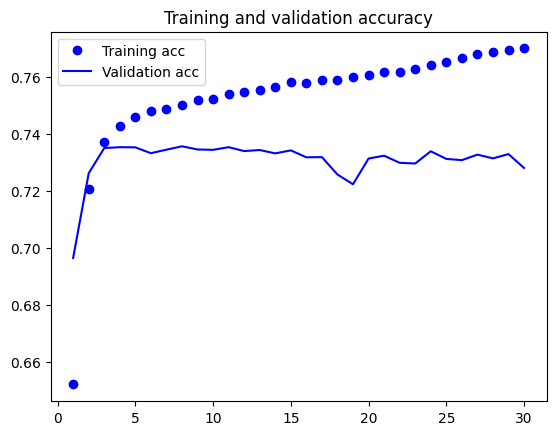

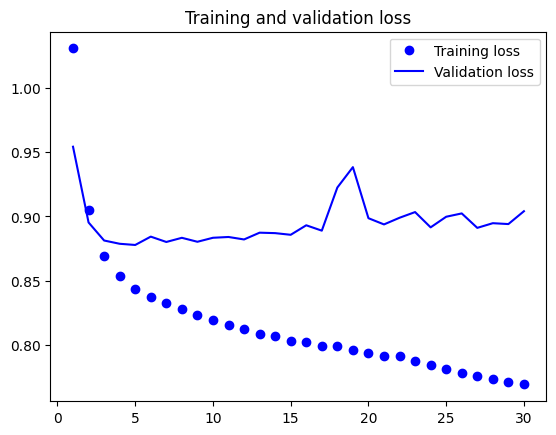

In [337]:
# Plot the Training and Validation Accuracy & Loss Scores
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [338]:
# Save the Model
#model.save('text_model_1.keras')

### Model #2  (Student Name: Lim Chang Ze)

In [26]:
# Build the Model
# Build the Model
y_train_netflix = y_train_netflix - 1  

model = Sequential()
model.add(keras.Input(shape=(maxlen,)))
model.add(Embedding(10000, 16)) #receive word embedding as input
model.add(SimpleRNN(5))
model.add(Dense(5, activation='softmax'))
model.summary()

# Train the Model
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),  
              metrics=['acc'])

history = model.fit(X_train_netflix_tokenized, y_train_netflix,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.2)

I0000 00:00:1738611908.465400   36236 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 5)              │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │            30 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,140 (625.55 KB)

 Trainable params: 160,140 (625.55 KB)

...

Epoch 1/30


I0000 00:00:1738611911.342002   37084 service.cc:148] XLA service 0x7f3c7c003000 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738611911.342476   37084 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-02-04 03:45:11.437580: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738611911.700786   37084 cuda_dnn.cc:529] Loaded cuDNN version 90300


   3/4000 ━━━━━━━━━━━━━━━━━━━━ 2:33 38ms/step - acc: 0.2969 - loss: 1.6082 

I0000 00:00:1738611915.044379   37084 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4000/4000 ━━━━━━━━━━━━━━━━━━━━ 73s 17ms/step - acc: 0.6246 - loss: 1.0524 - val_acc: 0.7254 - val_loss: 0.8576
Epoch 2/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 62s 16ms/step - acc: 0.7315 - loss: 0.8438 - val_acc: 0.7319 - val_loss: 0.8357
Epoch 3/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 64s 16ms/step - acc: 0.7387 - loss: 0.8139 - val_acc: 0.7341 - val_loss: 0.8205
Epoch 4/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 62s 16ms/step - acc: 0.7430 - loss: 0.7985 - val_acc: 0.7320 - val_loss: 0.8187
Epoch 5/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 66s 17ms/step - acc: 0.7458 - loss: 0.7832 - val_acc: 0.7369 - val_loss: 0.8088
Epoch 6/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 75s 19ms/step - acc: 0.7464 - loss: 0.7771 - val_acc: 0.7352 - val_loss: 0.8065
Epoch 7/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 68s 17ms/step - acc: 0.7435 - loss: 0.7832 - val_acc: 0.7336 - val_loss: 0.8071
Epoch 8/30
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 63s 16ms/step - acc: 0.7441 - loss: 0.7791 - val_acc: 0.7331 - val_loss: 0.8148
Epoch 9/30
4000/4000 ━━━━━━━━━━━━━━

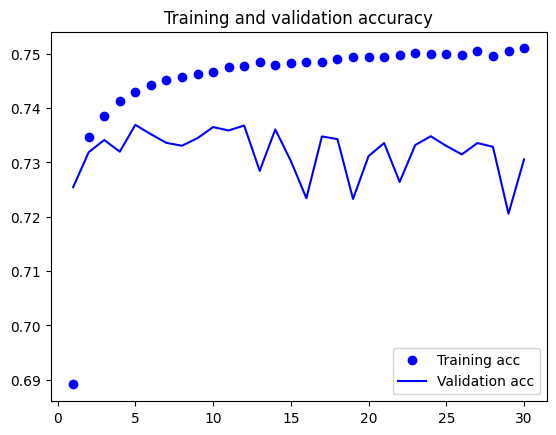

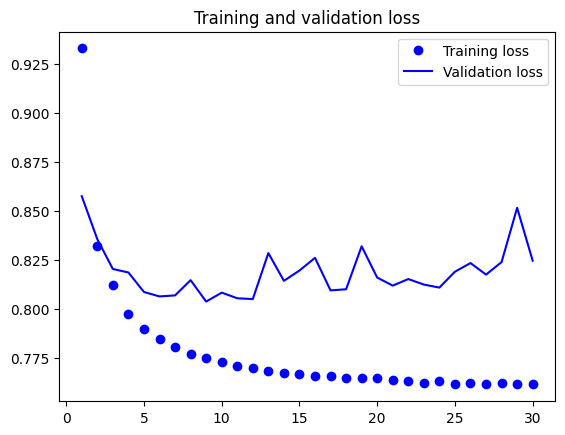

In [27]:
# Plot the Training and Validation Accuracy & Loss Scores
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [29]:
# Save the Model
model.save('models/netflix_model_1.keras')

### Model #3  (Student Name: Hpone Myint Myat Paing Sean)

In [342]:
# Build the Model


In [343]:
# Train the Model


In [344]:
# Plot the Training and Validation Accuracy & Loss Scores


In [345]:
# Save the Model
#model.save('text_model_2.keras')

### Model #4  (Student Name: Elvis Chan Jun Yu)

In [346]:
# Build the Model


In [347]:
# Train the Model


In [348]:
# Plot the Training and Validation Accuracy & Loss Scores


In [349]:
# Save the Model
#model.save('text_model_2.keras')

### Model #5  (Student Name: Tej)

In [350]:
# Build the Model


In [351]:
# Train the Model


In [352]:
# Plot the Training and Validation Accuracy & Loss Scores


In [353]:
# Save the Model
#model.save('text_model_2.keras')

## Step 3 – Evaluate the Model using Testing Data (Individual & Group)

In [354]:
# Model #1 (replicate where necessary for other models)
model1 = keras.models.load_model('text_model_1.keras')

ValueError: File not found: filepath=text_model_1.keras. Please ensure the file is an accessible `.keras` zip file.

In [30]:
# Model #2 (replicate where necessary for other models)
model2 = keras.models.load_model('models/netflix_model_1.keras')


In [ ]:
# Model #3 (replicate where necessary for other models)
model3 = keras.models.load_model('text_model_3.keras')


In [ ]:
# Model #4 (replicate where necessary for other models)
model4 = keras.models.load_model('text_model_4.keras')


In [ ]:
# Model #5 (replicate where necessary for other models)
model5 = keras.models.load_model('text_model_5.keras')


In [ ]:
# Save the Best Model
model.save('text_model_best.keras')

## Step 4 – Use the Best Model to make prediction (Group)

In [ ]:
best_model = keras.models.load_model('text_model_best.keras')

In [ ]:
# takes the user input
text_input = np.array([input()])

In [ ]:
# convert the user input into numeric tensor


In [ ]:
# show the model output using predict function

